In [3]:
# Two separate balanced PDFs: accuracy_vs_dim and accuracy_vs_var (response vs oddball_idx)

import os, re, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FuncFormatter

BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
OUTP = BASE / 'plots' / 'publication'
OUTP.mkdir(parents=True, exist_ok=True)
BAL_OUT = BASE / 'balanced_output'
BAL_DATA = BASE / 'balanced_data'

DOMAINS = [
  ('regular_polygons', r'^regular_polygons_(\d)dim_var(\d+)_dim\d+\.csv$', 'None/gemini-flash'),
  ('glyphs',           r'^glyphs_dim(\d)_var(\d+)_dim\d+\.csv$',           'glyphs/gemini-flash'),
  ('nuts_and_bolts',   r'^nab_dim(\d)_var(\d+)_dim\d+\.csv$',               'nuts_and_bolts/gemini-flash'),
  ('totems',           r'^totems_(\d)mod_var(\d+)_dim\d+\.csv$',            'totems/gemini-flash'),
]

sns.set_theme(style='white')
plt.rcParams.update({
  'font.family': 'DejaVu Sans',
  'font.size': 10.0,
  'axes.labelsize': 10.0,
  'axes.titlesize': 10.0,
  'xtick.labelsize': 9.5,
  'ytick.labelsize': 9.5,
  'axes.linewidth': 0.9,
  'lines.linewidth': 1.8,
  'savefig.bbox': 'tight',
  'savefig.pad_inches': 0.08,
})

def read_trials_map(path: Path):
  if not path or not path.exists(): return {}
  m={}
  with open(path) as f:
    for ln in f:
      try:
        j=json.loads(ln); m[int(j['trial_idx'])]=int(j['oddball_idx'])
      except: pass
  return m

def load_balanced_accuracy(mode: str) -> pd.DataFrame:
  rec=[]
  for domain, pat_str, out_rel in DOMAINS:
    pat=re.compile(pat_str)
    out_dir=BAL_OUT/mode/out_rel
    if not out_dir.exists(): continue
    for f in sorted(out_dir.glob('*.csv')):
      m=pat.search(f.name)
      if not m: continue
      lvl,var=int(m.group(1)),int(m.group(2))
      data_root=BAL_DATA/mode/domain
      trials=None
      for cand in [data_root/f'dim{lvl}'/f'var{var}'/'trials.jsonl', data_root/f'{lvl}mod'/f'var{var}'/'trials.jsonl']:
        if cand.exists(): trials=cand; break
      idx2odd=read_trials_map(trials)
      df=pd.read_csv(f)
      # Identify model response column
      resp_col=None
      for c in ('response','model_response','prediction','pred','model_answer','model_pred'):
        if c in df.columns:
          resp_col=c; break
      if 'trial_idx' not in df.columns:
        df=df.reset_index().rename(columns={'index':'trial_idx'})
      # Ground-truth oddball index
      if 'oddball_idx' in df.columns:
        gt=df['oddball_idx']
      else:
        df['__odd']=df['trial_idx'].map(lambda t: idx2odd.get(int(t)))
        gt=df['__odd']
      if resp_col is None:
        continue
      # Parse numeric indices from responses and gt, handling strings like 'tile_3'
      resp_str=df[resp_col].astype(str).str.strip()
      resp_num=pd.to_numeric(resp_str.str.extract(r'(\d+)')[0], errors='coerce')
      gt_num=pd.to_numeric(pd.Series(gt).astype(str).str.extract(r'(\d+)')[0], errors='coerce')
      # Heuristic alignment for 1-based vs 0-based
      if resp_num.notna().any() and gt_num.notna().any():
        rmin,rmax=resp_num.min(),resp_num.max(); gmin,gmax=gt_num.min(),gt_num.max()
        if (pd.notna(rmin) and pd.notna(rmax) and pd.notna(gmin) and pd.notna(gmax)
            and 1 <= rmin <= 6 and 1 <= rmax <= 6 and 0 <= gmin <= 5 and 0 <= gmax <= 5):
          resp_num=resp_num-1
      corr=(resp_num.astype('Int64')==gt_num.astype('Int64')).astype('Int64').fillna(0).astype(int)
      rec.append(pd.DataFrame({'domain':domain,'dim':lvl,'var':var,'trial_idx':df['trial_idx'],'is_correct':corr}))
  return pd.concat(rec, ignore_index=True) if rec else pd.DataFrame(columns=['domain','dim','var','trial_idx','is_correct'])

def ci_boot(values, B=2500, alpha=0.05):
  a=np.asarray(values,float)
  if a.size==0: return (np.nan,np.nan,np.nan)
  boots=[np.mean(np.random.choice(a,size=a.size,replace=True)) for _ in range(B)]
  return float(a.mean()), float(np.percentile(boots,100*alpha/2)), float(np.percentile(boots,100*(1-alpha/2)))

def style_axes(ax, title):
  ax.set_title(title, pad=8)
  ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
  ax.yaxis.set_major_locator(MultipleLocator(0.1)); ax.yaxis.set_minor_locator(MultipleLocator(0.05))
  ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'{y:.2f}'))
  ax.grid(axis='y', which='major', color='#b0b0b0', alpha=0.24, linewidth=0.7)
  ax.grid(axis='y', which='minor', alpha=0.14, linewidth=0.45)
  ax.set_ylim(0,1); ax.set_ylabel('Accuracy', labelpad=6); ax.margins(x=0.05)

# Accuracy vs dim (balanced dim)
acc_dimB = load_balanced_accuracy('dim_balanced')
P1 = []
for x,g in sorted(acc_dimB.groupby('dim')):
  m,lo,hi=ci_boot(g['is_correct'].values)
  P1.append((x,m,lo,hi,len(g)))
P1 = pd.DataFrame(P1, columns=['dim','mean','lo','hi','n']).sort_values('dim') if P1 else pd.DataFrame(columns=['dim','mean','lo','hi','n'])
fig,ax=plt.subplots(figsize=(4.0,3.4), constrained_layout=True)
if not P1.empty:
  ax.plot(P1['dim'],P1['mean'],color='#1f78b4',marker='o',markersize=4.2,lw=1.8)
  ax.fill_between(P1['dim'],P1['lo'],P1['hi'],color='#1f78b4',alpha=0.15,linewidth=0)
  for _,r in P1.iterrows():
    ax.annotate(f"n={int(r['n'])}",(r['dim'],r['mean']),xytext=(0,-10),textcoords='offset points',ha='center',va='top',fontsize=7.5,color='#777777')
ax.set_xlabel('Dim'); style_axes(ax,'Accuracy vs Dimension')
fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.18)
fig.savefig(OUTP/'balanced_accuracy_vs_dim.pdf'); plt.close(fig)
print('Saved:', OUTP/'balanced_accuracy_vs_dim.pdf')

# Accuracy vs var (balanced var)
acc_varB = load_balanced_accuracy('var_balanced')
P2 = []
for x,g in sorted(acc_varB.groupby('var')):
  m,lo,hi=ci_boot(g['is_correct'].values)
  P2.append((x,m,lo,hi,len(g)))
P2 = pd.DataFrame(P2, columns=['var','mean','lo','hi','n']).sort_values('var') if P2 else pd.DataFrame(columns=['var','mean','lo','hi','n'])
fig,ax=plt.subplots(figsize=(4.0,3.4), constrained_layout=True)
if not P2.empty:
  ax.plot(P2['var'],P2['mean'],color='#6F4C9B',marker='o',markersize=4.2,lw=1.8)
  ax.fill_between(P2['var'],P2['lo'],P2['hi'],color='#6F4C9B',alpha=0.15,linewidth=0)
  for _,r in P2.iterrows():
    ax.annotate(f"n={int(r['n'])}",(r['var'],r['mean']),xytext=(0,-10),textcoords='offset points',ha='center',va='top',fontsize=7.5,color='#777777')
ax.set_xlabel('Var'); style_axes(ax,'Accuracy vs Variance')
fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.18)
fig.savefig(OUTP/'balanced_accuracy_vs_var.pdf'); plt.close(fig)
print('Saved:', OUTP/'balanced_accuracy_vs_var.pdf')

/tmp/ipykernel_2833790/967721195.py:121: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.18)


Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_accuracy_vs_dim.pdf
Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_accuracy_vs_var.pdf


/tmp/ipykernel_2833790/967721195.py:139: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.18)


In [4]:
# Build two example PDFs from summary images: one by dim (1..3), one by var (0..5)

import os
from pathlib import Path
import re
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
OUTP = BASE / 'plots' / 'publication'
BAL_DATA = BASE / 'balanced_data'

random.seed(42)

# Helper: find a representative summary image in a bucket
# Preference order: regular_polygons -> glyphs -> nuts_and_bolts -> totems
DOM_ORDER = ['regular_polygons','glyphs','nuts_and_bolts','totems']

def find_summary_for(mode: str, dim: int = None, var: int = None):
  for domain in DOM_ORDER:
    droot = BAL_DATA / mode / domain
    if dim is not None:
      ddir = droot / f'dim{dim}' / f'var{var}'
    else:
      # For totems dim uses mod count in file structure, but directory is still dimX/varY
      # so dim must be provided; for var-balanced we iterate dims that include this var
      continue
    summ = ddir / 'summaries'
    if summ.exists():
      # Prefer summary=trial*.png
      cands = sorted([p for p in summ.glob('summary=trial*.png')])
      if not cands:
        cands = sorted([p for p in summ.glob('*.png')])
      if cands:
        return domain, cands[len(cands)//3]
  return None, None

# DIM EXAMPLES: pick one image each from dim1,var0 ; dim2,var1 ; dim3,var2 (mid-low var levels)
DIM_CHOICES = [(1,0),(2,1),(3,2)]

# Build a wide PDF (landscape) with 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.6))
for ax,(d,v) in zip(axes, DIM_CHOICES):
  domain, imgp = find_summary_for('dim_balanced', dim=d, var=v)
  ax.axis('off')
  if imgp and imgp.exists():
    img = Image.open(imgp)
    ax.imshow(img)
    ttl = f'dim {d}  |  var {v}  |  {domain.replace("_"," ")}'
    ax.set_title(ttl, fontsize=11, pad=8)
  else:
    ax.text(0.5,0.5,f'No summary found\n(dim{d}/var{v})',ha='center',va='center',fontsize=11)

fig.suptitle('Representative Trials by Dimension', fontsize=12.5, y=0.98)
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.04, wspace=0.06)
fig.savefig(OUTP / 'balanced_examples_by_dim.pdf')
plt.close(fig)
print('Saved:', OUTP / 'balanced_examples_by_dim.pdf')

# VAR EXAMPLES: pick one image each from dim that supports var level
# Use dim 3 when available; otherwise dim 2 for var<=3; dim 1 only for var<=1
VAR_DIM_FOR = {0:3,1:3,2:3,3:3,4:3,5:3}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))
for ax, var in zip(axes.flatten(), [0,1,2,3,4,5]):
  # Choose a supporting dim directory that exists
  chosen_domain, chosen_img = None, None
  for dim_try in ([3,2,1] if var>=2 else [2,1,3]):
    domain, imgp = find_summary_for('var_balanced', dim=dim_try, var=var)
    if imgp:
      chosen_domain, chosen_img = domain, imgp
      break
  ax.axis('off')
  if chosen_img and Path(chosen_img).exists():
    img = Image.open(chosen_img)
    ax.imshow(img)
    ttl = f'var {var}  |  dim {dim_try}  |  {chosen_domain.replace("_"," ")}'
    ax.set_title(ttl, fontsize=11, pad=8)
  else:
    ax.text(0.5,0.5,f'No summary found\n(var{var})',ha='center',va='center',fontsize=11)

fig.suptitle('Representative Trials by Variance', fontsize=12.5, y=0.98)
fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.04, wspace=0.06, hspace=0.12)
fig.savefig(OUTP / 'balanced_examples_by_var.pdf')
plt.close(fig)
print('Saved:', OUTP / 'balanced_examples_by_var.pdf')


Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_by_dim.pdf
Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_by_var.pdf


In [5]:
# Combined examples PDF: top row by Dimension (3), bottom two rows by Variance (0..5)

from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt

BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
OUTP = BASE / 'plots' / 'publication'
BAL_DATA = BASE / 'balanced_data'

random.seed(42)

DOM_ORDER = ['regular_polygons','glyphs','nuts_and_bolts','totems']

def label_for_domain(domain: str) -> str:
  return 'polygons' if domain == 'regular_polygons' else domain.replace('_',' ')

def find_summary_for(mode: str, dim: int, var: int):
  for domain in DOM_ORDER:
    ddir = BAL_DATA / mode / domain / f'dim{dim}' / f'var{var}' / 'summaries'
    if ddir.exists():
      cands = sorted(ddir.glob('summary=trial*.png')) or sorted(ddir.glob('*.png'))
      if cands:
        return domain, cands[len(cands)//3]
  return None, None

# GridSpec layout with dedicated title rows to avoid overlap
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(13.5, 12.0))
gs = gridspec.GridSpec(
  nrows=5, ncols=3,
  height_ratios=[0.10, 1.0, 0.10, 1.0, 1.0],
  hspace=0.18, wspace=0.06,
  left=0.02, right=0.98, top=0.96, bottom=0.04,
)

# Title row 0
ax_t1 = fig.add_subplot(gs[0, :]); ax_t1.axis('off')
ax_t1.text(0.5, 0.5, 'Representative Trials by Dimension', ha='center', va='center', fontsize=13)

# Row 1: dims
for j,(dim,var) in enumerate([(1,0),(2,1),(3,2)]):
  ax = fig.add_subplot(gs[1, j])
  ax.axis('off')
  domain, imgp = find_summary_for('dim_balanced', dim=dim, var=var)
  if imgp:
    ax.imshow(Image.open(imgp))
    ax.set_title(f'dim {dim}  |  var {var}  |  {label_for_domain(domain)}', fontsize=11, pad=8)
  else:
    ax.text(0.5,0.5,f'No summary found\n(dim{dim}/var{var})',ha='center',va='center',fontsize=11)

# Title row 2
ax_t2 = fig.add_subplot(gs[2, :]); ax_t2.axis('off')
ax_t2.text(0.5, 0.5, 'Representative Trials by Variance', ha='center', va='center', fontsize=13)

# Rows 3-4: vars 0..5
vars_list = [0,1,2,3,4,5]
for idx,var in enumerate(vars_list):
  i = 3 + idx//3
  j = idx % 3
  ax = fig.add_subplot(gs[i, j])
  ax.axis('off')
  chosen = None
  for dim_try in ([3,2,1] if var>=2 else [2,1,3]):
    domain, imgp = find_summary_for('var_balanced', dim=dim_try, var=var)
    if imgp:
      chosen = (domain, imgp, dim_try)
      break
  if chosen:
    domain, imgp, dim_try = chosen
    ax.imshow(Image.open(imgp))
    ax.set_title(f'var {var}  |  dim {dim_try}  |  {label_for_domain(domain)}', fontsize=11, pad=8)
  else:
    ax.text(0.5,0.5,f'No summary found\n(var{var})',ha='center',va='center',fontsize=11)

fig.savefig(OUTP / 'balanced_examples_combined.pdf')
plt.close(fig)
print('Saved:', OUTP / 'balanced_examples_combined.pdf')


Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_combined.pdf


In [6]:
# Per-domain combined examples PDFs for glyphs, nuts_and_bolts, totems

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
OUTP = BASE / 'plots' / 'publication'
BAL_DATA = BASE / 'balanced_data'

DOM_TO_LABEL = {
  'regular_polygons': 'polygons',
  'glyphs': 'glyphs',
  'nuts_and_bolts': 'nuts and bolts',
  'totems': 'totems',
}

# Determine for each domain how the dim folders are named
# All balanced_data use dimX/varY

def label_for_domain(domain: str) -> str:
  return DOM_TO_LABEL.get(domain, domain.replace('_',' '))

def find_summary_for(domain: str, mode: str, dim: int, var: int):
  ddir = BAL_DATA / mode / domain / f'dim{dim}' / f'var{var}' / 'summaries'
  if ddir.exists():
    cands = sorted(ddir.glob('summary=trial*.png')) or sorted(ddir.glob('*.png'))
    if cands:
      return cands[len(cands)//3]
  return None

# Create the combined 3x3 examples layout for a single domain
# Top row: dim examples (1,0) (2,1) (3,2)
# Bottom two rows: var examples (0..5), picking any supporting dim within this domain

def build_combined_examples_for_domain(domain: str):
  fig = plt.figure(figsize=(13.5, 12.0))
  gs = gridspec.GridSpec(
    nrows=5, ncols=3,
    height_ratios=[0.10, 1.0, 0.10, 1.0, 1.0],
    hspace=0.18, wspace=0.06,
    left=0.02, right=0.98, top=0.96, bottom=0.04,
  )

  # Title row 0
  ax_t1 = fig.add_subplot(gs[0, :]); ax_t1.axis('off')
  ax_t1.text(0.5, 0.5, 'Representative Trials by Dimension', ha='center', va='center', fontsize=13)

  # Row 1: dims
  for j,(dim,var) in enumerate([(1,0),(2,1),(3,2)]):
    ax = fig.add_subplot(gs[1, j])
    ax.axis('off')
    imgp = find_summary_for(domain, 'dim_balanced', dim=dim, var=var)
    if imgp:
      ax.imshow(Image.open(imgp))
      ax.set_title(f'dim {dim}  |  var {var}  |  {label_for_domain(domain)}', fontsize=11, pad=8)
    else:
      ax.text(0.5,0.5,f'No summary found\n(dim{dim}/var{var})',ha='center',va='center',fontsize=11)

  # Title row 2
  ax_t2 = fig.add_subplot(gs[2, :]); ax_t2.axis('off')
  ax_t2.text(0.5, 0.5, 'Representative Trials by Variance', ha='center', va='center', fontsize=13)

  # Rows 3-4: vars 0..5
  vars_list = [0,1,2,3,4,5]
  for idx,var in enumerate(vars_list):
    i = 3 + idx//3
    j = idx % 3
    ax = fig.add_subplot(gs[i, j])
    ax.axis('off')

    # Choose a supporting dim that exists within this domain
    chosen_img = None; chosen_dim = None
    for dim_try in ([3,2,1] if var>=2 else [2,1,3]):
      imgp = find_summary_for(domain, 'var_balanced', dim=dim_try, var=var)
      if imgp:
        chosen_img = imgp; chosen_dim = dim_try
        break

    if chosen_img:
      ax.imshow(Image.open(chosen_img))
      ax.set_title(f'var {var}  |  dim {chosen_dim}  |  {label_for_domain(domain)}', fontsize=11, pad=8)
    else:
      ax.text(0.5,0.5,f'No summary found\n(var{var})',ha='center',va='center',fontsize=11)

  outp = OUTP / f'balanced_examples_combined__{domain}.pdf'
  fig.savefig(outp)
  plt.close(fig)
  print('Saved:', outp)

# Build for the three requested domains
for dom in ['glyphs','nuts_and_bolts','totems']:
  build_combined_examples_for_domain(dom)



Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_combined__glyphs.pdf
Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_combined__nuts_and_bolts.pdf
Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_combined__totems.pdf


In [7]:
# Master 2x2 grid: combine per-domain combined plots with precise alignment

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
OUTP = BASE / 'plots' / 'publication'
BAL_DATA = BASE / 'balanced_data'

DOM_TO_LABEL = {
  'regular_polygons': 'polygons',
  'glyphs': 'glyphs',
  'nuts_and_bolts': 'nuts and bolts',
  'totems': 'totems',
}

def label_for_domain(domain: str) -> str:
  return DOM_TO_LABEL.get(domain, domain.replace('_',' '))

def find_summary_for(domain: str, mode: str, dim: int, var: int):
  ddir = BAL_DATA / mode / domain / f'dim{dim}' / f'var{var}' / 'summaries'
  if ddir.exists():
    cands = sorted(ddir.glob('summary=trial*.png')) or sorted(ddir.glob('*.png'))
    if cands:
      return cands[len(cands)//3]
  return None

# Render one domain's combined grid (5x3) into a given sub-GridSpec cell

def render_domain_into(fig, cell, domain: str):
  igs = gridspec.GridSpecFromSubplotSpec(
    5, 3, subplot_spec=cell,
    height_ratios=[0.10, 1.0, 0.10, 1.0, 1.0],
    hspace=0.18, wspace=0.06,
  )
  # Title row 0
  ax_t1 = fig.add_subplot(igs[0, :]); ax_t1.axis('off')
  ax_t1.text(0.5, 0.5, 'Representative Trials by Dimension', ha='center', va='center', fontsize=13)
  # Row 1: dims
  for j,(dim,var) in enumerate([(1,0),(2,1),(3,2)]):
    ax = fig.add_subplot(igs[1, j]); ax.axis('off')
    imgp = find_summary_for(domain, 'dim_balanced', dim=dim, var=var)
    if imgp:
      ax.imshow(Image.open(imgp))
      ax.set_title(f'dim {dim}  |  var {var}  |  {label_for_domain(domain)}', fontsize=11, pad=8)
    else:
      ax.text(0.5,0.5,f'No summary found\n(dim{dim}/var{var})',ha='center',va='center',fontsize=11)
  # Title row 2
  ax_t2 = fig.add_subplot(igs[2, :]); ax_t2.axis('off')
  ax_t2.text(0.5, 0.5, 'Representative Trials by Variance', ha='center', va='center', fontsize=13)
  # Rows 3-4: vars 0..5
  vars_list = [0,1,2,3,4,5]
  for idx,var in enumerate(vars_list):
    i = 3 + idx//3; j = idx % 3
    ax = fig.add_subplot(igs[i, j]); ax.axis('off')
    chosen_img = None; chosen_dim = None
    for dim_try in ([3,2,1] if var>=2 else [2,1,3]):
      imgp = find_summary_for(domain, 'var_balanced', dim=dim_try, var=var)
      if imgp:
        chosen_img = imgp; chosen_dim = dim_try
        break
    if chosen_img:
      ax.imshow(Image.open(chosen_img))
      ax.set_title(f'var {var}  |  dim {chosen_dim}  |  {label_for_domain(domain)}', fontsize=11, pad=8)
    else:
      ax.text(0.5,0.5,f'No summary found\n(var{var})',ha='center',va='center',fontsize=11)

# Build the 2x2 master figure
fig = plt.figure(figsize=(27.0, 24.0))
outer = gridspec.GridSpec(
  2, 2,
  left=0.02, right=0.98, top=0.98, bottom=0.02,
  wspace=0.07, hspace=0.08,
)

order = [
  ('regular_polygons', (0,0)),
  ('glyphs',           (0,1)),
  ('nuts_and_bolts',   (1,0)),
  ('totems',           (1,1)),
]

for domain, (r,c) in order:
  render_domain_into(fig, outer[r, c], domain)

outp = OUTP / 'balanced_examples_master_2x2.pdf'
fig.savefig(outp)
plt.close(fig)
print('Saved:', outp)


Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/balanced_examples_master_2x2.pdf


In [8]:
# Regular polygons — curated, no-label figure (DreamCoder-quality aesthetics)
# dim1: 13 samples = (n_sides {3,4,5,6} × edge_type {straight, concave, convex}) + optional circle if present
# dim2: 20 samples = (n_copies {3,4,5,6} × transform_type {radial, spiral, line, scale_origin, scale_outward})
# dim3: 16 samples = (composition_type {none,nested,layered,rotated} × base_transform {radial,line,spiral,scale})
# Group similar transforms; randomized selection within each category; no titles/labels.

import json, random
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
ROOT = BASE / 'balanced_data' / 'dim_balanced' / 'regular_polygons'
OUTP = BASE / 'plots' / 'publication'
OUTP.mkdir(parents=True, exist_ok=True)

random.seed(42)

# Canonical orders
NSIDES = [3, 4, 5, 6]
EDGE_TYPES = ['straight', 'concave', 'convex']  # observed in dim1
NCOPIES = [3, 4, 5, 6]
DIM2_TRANSFORMS = ['radial', 'spiral', 'line', 'scale_origin', 'scale_outward']
COMPOSITIONS = ['none', 'nested', 'layered', 'rotated']
DIM3_BASE_TRANSFORMS = ['radial', 'line', 'spiral', 'scale']  # scale groups origin/outward

def var_dirs_for_dim(dim: int):
  ddir = ROOT / f'dim{dim}'
  if not ddir.exists():
    return []
  return sorted(ddir.glob('var*'))

def read_trials(vdir: Path, max_lines=20000):
  out = []
  tjson = vdir / 'trials.jsonl'
  if not tjson.exists():
    return out
  try:
    with open(tjson) as f:
      for _ in range(max_lines):
        try:
          out.append(json.loads(next(f)))
        except StopIteration:
          break
        except Exception:
          continue
  except Exception:
    pass
  return out

def tile_image_path(vdir: Path, trial_idx: int, tile_idx: int):
  p = vdir / 'trials' / f'trial={trial_idx}_{tile_idx}.png'
  return p if p.exists() else None

def norm(x): 
  return str(x).strip().lower() if x is not None else None

def extract_tile_features(tile: dict):
  f = tile.get('features') or {}
  n_sides = f.get('n_sides') or f.get('num_sides') or f.get('sides')
  try:
    n_sides = int(n_sides)
  except Exception:
    pass
  edge_type = norm(f.get('edge_type'))
  shape = norm(f.get('shape') or f.get('shape_name'))
  is_circle = (shape == 'circle') or (isinstance(n_sides, int) and n_sides == 0) or (norm(f.get('is_circle')) in ('true','1'))
  n_copies = f.get('n_copies')
  try:
    n_copies = int(n_copies)
  except Exception:
    pass
  ttype = norm(f.get('transform_type'))
  ctype = norm(f.get('composition_type')) or 'none'
  # Normalize edge synonyms (if any appear)
  if edge_type in ('line', 'straight_line'):
    edge_type = 'straight'
  if edge_type in ('concave_arc',):
    edge_type = 'concave'
  if edge_type in ('convex_arc',):
    edge_type = 'convex'
  return {
    'n_sides': n_sides,
    'edge_type': edge_type,
    'is_circle': is_circle,
    'n_copies': n_copies,
    'transform_type': ttype,
    'composition_type': ctype,
  }

def load_img_border(p: Path, border_px=2):
  try:
    im = Image.open(p).convert('RGB')
    im = ImageOps.expand(im, border=border_px, fill='white')
    return im
  except Exception:
    return None

# Build pools for categories
dim1_pool = defaultdict(list)        # key: ('poly', n_sides, edge_type) or ('circle',)
dim2_pool = defaultdict(list)        # key: (n_copies, transform_type)
dim3_pool = defaultdict(list)        # key: (composition_type, base_transform)

# DIM1: scan var0, var1
for vdir in var_dirs_for_dim(1):
  trials = read_trials(vdir)
  random.shuffle(trials)
  for tr in trials:
    t_idx = tr.get('trial_idx')
    tiles = tr.get('tiles') or []
    for t_i, tile in enumerate(tiles, start=1):
      feats = extract_tile_features(tile)
      imgp = tile_image_path(vdir, int(t_idx), t_i) if t_idx is not None else None
      if not imgp: 
        continue
      if feats['is_circle']:
        dim1_pool[('circle',)].append(imgp)
      if isinstance(feats['n_sides'], int) and feats['n_sides'] in NSIDES and feats['edge_type'] in EDGE_TYPES:
        dim1_pool[('poly', feats['n_sides'], feats['edge_type'])].append(imgp)

# DIM2: scan all var*
for vdir in var_dirs_for_dim(2):
  trials = read_trials(vdir)
  random.shuffle(trials)
  for tr in trials:
    t_idx = tr.get('trial_idx')
    tiles = tr.get('tiles') or []
    for t_i, tile in enumerate(tiles, start=1):
      feats = extract_tile_features(tile)
      imgp = tile_image_path(vdir, int(t_idx), t_i) if t_idx is not None else None
      if not imgp: 
        continue
      if feats['n_copies'] in NCOPIES and feats['transform_type'] in DIM2_TRANSFORMS:
        dim2_pool[(feats['n_copies'], feats['transform_type'])].append(imgp)

# DIM3: scan all var* (do not restrict to comp_scale oddball)
for vdir in var_dirs_for_dim(3):
  trials = read_trials(vdir)
  random.shuffle(trials)
  for tr in trials:
    t_idx = tr.get('trial_idx')
    tiles = tr.get('tiles') or []
    for t_i, tile in enumerate(tiles, start=1):
      feats = extract_tile_features(tile)
      imgp = tile_image_path(vdir, int(t_idx), t_i) if t_idx is not None else None
      if not imgp:
        continue
      base = feats['transform_type']
      if base in ('scale_origin','scale_outward'):
        base_grp = 'scale'
      else:
        base_grp = base
      if base_grp in DIM3_BASE_TRANSFORMS and feats['composition_type'] in COMPOSITIONS:
        dim3_pool[(feats['composition_type'], base_grp)].append(imgp)

def pick_one(cands):
  if not cands:
    return None
  return random.choice(cands)

# Assemble targets
# dim1: 12 polygon categories + optional circle
dim1_targets = [('poly', n, e) for n in NSIDES for e in EDGE_TYPES]
dim1_paths = []
for key in dim1_targets:
  imgp = pick_one(dim1_pool.get(key, []))
  if imgp:
    dim1_paths.append(imgp)
# try to add circle if present
circ = pick_one(dim1_pool.get(('circle',), []))
if circ:
  dim1_paths.append(circ)
# Trim to exactly 13 if we found more for any reason
dim1_paths = dim1_paths[:13]

# dim2: 4×5 exact
dim2_paths = []
for n in NCOPIES:
  for t in DIM2_TRANSFORMS:
    dim2_paths.append(pick_one(dim2_pool.get((n, t), [])))
# dim3: 4×4 exact (composition rows × base_transform cols)
dim3_paths = []
for comp in COMPOSITIONS:
  for base in DIM3_BASE_TRANSFORMS:
    dim3_paths.append(pick_one(dim3_pool.get((comp, base), [])))

# Aesthetic layout helpers
def draw_block(fig, spec, paths, ncols, pad=0.006, wspace=0.035, hspace=0.035, corner=0.02):
  # Arrange paths across rows/cols; draw subtle rounded border behind images
  valid = [p for p in paths if p]
  n = len(valid)
  nrows = (n + ncols - 1) // ncols
  inner = gridspec.GridSpecFromSubplotSpec(nrows, ncols, subplot_spec=spec, wspace=wspace, hspace=hspace)
  idx = 0
  for r in range(nrows):
    for c in range(ncols):
      ax = fig.add_subplot(inner[r, c])
      ax.set_xticks([]); ax.set_yticks([]); ax.set_frame_on(False)
      if idx < n:
        im = load_img_border(valid[idx], border_px=2)
        if im:
          ax.imshow(im)
        # subtle rounded border (in axes coords)
        bb = FancyBboxPatch((pad, pad), 1-2*pad, 1-2*pad,
                            boxstyle=f"round,pad={pad},rounding_size={corner}",
                            linewidth=0.6, edgecolor=(0,0,0,0.12), facecolor='none', transform=ax.transAxes)
        ax.add_patch(bb)
        idx += 1
      else:
        # Empty cell
        pass

# Choose columns per block for comfortable sizing
# dim1: 13 items → 5 columns (3 rows: 5+5+3)
# dim2: fixed 5×4 grid
# dim3: fixed 4×4 grid
cols_dim1 = 5
cols_dim2 = 5
cols_dim3 = 4

# Compute figure size (balance readability and density)
# width ~ 2.2 in per column, height per block ~ rows * 2.2 + margins
rows_dim1 = (len([p for p in dim1_paths if p]) + cols_dim1 - 1) // cols_dim1 or 1
rows_dim2 = 4
rows_dim3 = 4
fig_w = max(14.0, min(26.0, 2.2 * max(cols_dim1, cols_dim2, cols_dim3)))
fig_h = 2.2 * rows_dim1 + 2.2 * rows_dim2 + 2.2 * rows_dim3 + 1.2  # extra margin

fig = plt.figure(figsize=(fig_w, fig_h))
outer = gridspec.GridSpec(3, 1, left=0.02, right=0.98, top=0.985, bottom=0.02, hspace=0.12)

draw_block(fig, outer[0], dim1_paths, cols_dim1, wspace=0.04, hspace=0.04, corner=0.018)
draw_block(fig, outer[1], dim2_paths, cols_dim2, wspace=0.045, hspace=0.055, corner=0.018)
draw_block(fig, outer[2], dim3_paths, cols_dim3, wspace=0.045, hspace=0.055, corner=0.018)

outp = OUTP / 'stimulus_variability_regular_polygons_curated_no_labels_v2.pdf'
fig.savefig(outp, dpi=300)
plt.close(fig)

print('Saved:', outp)
print('dim1 filled:', len([p for p in dim1_paths if p]), 'dim2 filled:', len([p for p in dim2_paths if p]), 'dim3 filled:', len([p for p in dim3_paths if p]))

Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_variability_regular_polygons_curated_no_labels_v2.pdf
dim1 filled: 12 dim2 filled: 20 dim3 filled: 16


CREATING PERFECT STIMULUS VARIABILITY FIGURES

Found 4 domains:
  - regular_polygons → Regular Polygons
  - nuts_and_bolts → Nuts & Bolts
  - totems → Totems
  - glyphs → Glyphs

COLLECTING DIVERSE IMAGES

    dim1: 24 total images from 2 variants
           Selected 24 diverse samples
    dim2: 960 total images from 4 variants
           Selected 60 diverse samples
    dim3: 23040 total images from 6 variants
           Selected 60 diverse samples

    dim1: 16 total images from 2 variants
           Selected 16 diverse samples
    dim2: 256 total images from 4 variants
           Selected 60 diverse samples
    dim3: 3072 total images from 6 variants
           Selected 60 diverse samples

    dim1: 18 total images from 2 variants
           Selected 18 diverse samples
    dim2: 324 total images from 4 variants
           Selected 60 diverse samples
    dim3: 4374 total images from 6 variants
           Selected 60 diverse samples

    dim1: 18 total images from 2 variants
          

/tmp/ipykernel_2833790/1593303237.py:477: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_regular_polygons_perfect.pdf
  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_regular_polygons_perfect.png

Creating figure for Nuts & Bolts...

  Layout for Nuts & Bolts:
    Dim 1: 12 images in 4×3 grid
    Dim 2: 20 images in 5×4 grid
    Dim 3: 16 images in 4×4 grid


/tmp/ipykernel_2833790/1593303237.py:477: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_nuts_and_bolts_perfect.pdf
  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_nuts_and_bolts_perfect.png

Creating figure for Totems...

  Layout for Totems:
    Dim 1: 12 images in 4×3 grid
    Dim 2: 20 images in 5×4 grid
    Dim 3: 16 images in 4×4 grid


...

  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_totems_perfect.pdf
  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_totems_perfect.png

Creating figure for Glyphs...

  Layout for Glyphs:
    Dim 1: 12 images in 4×3 grid
    Dim 2: 20 images in 5×4 grid
    Dim 3: 16 images in 4×4 grid


/tmp/ipykernel_2833790/1593303237.py:477: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_glyphs_perfect.pdf
  ✓ Saved: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_glyphs_perfect.png

CREATING COMBINED FIGURE


/tmp/ipykernel_2833790/1593303237.py:583: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



✓ Saved combined: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_all_domains_combined_perfect.pdf
✓ Saved combined: /scratch/gpfs/nb0564/vlm_reasoning/plots/publication/stimulus_all_domains_combined_perfect.png


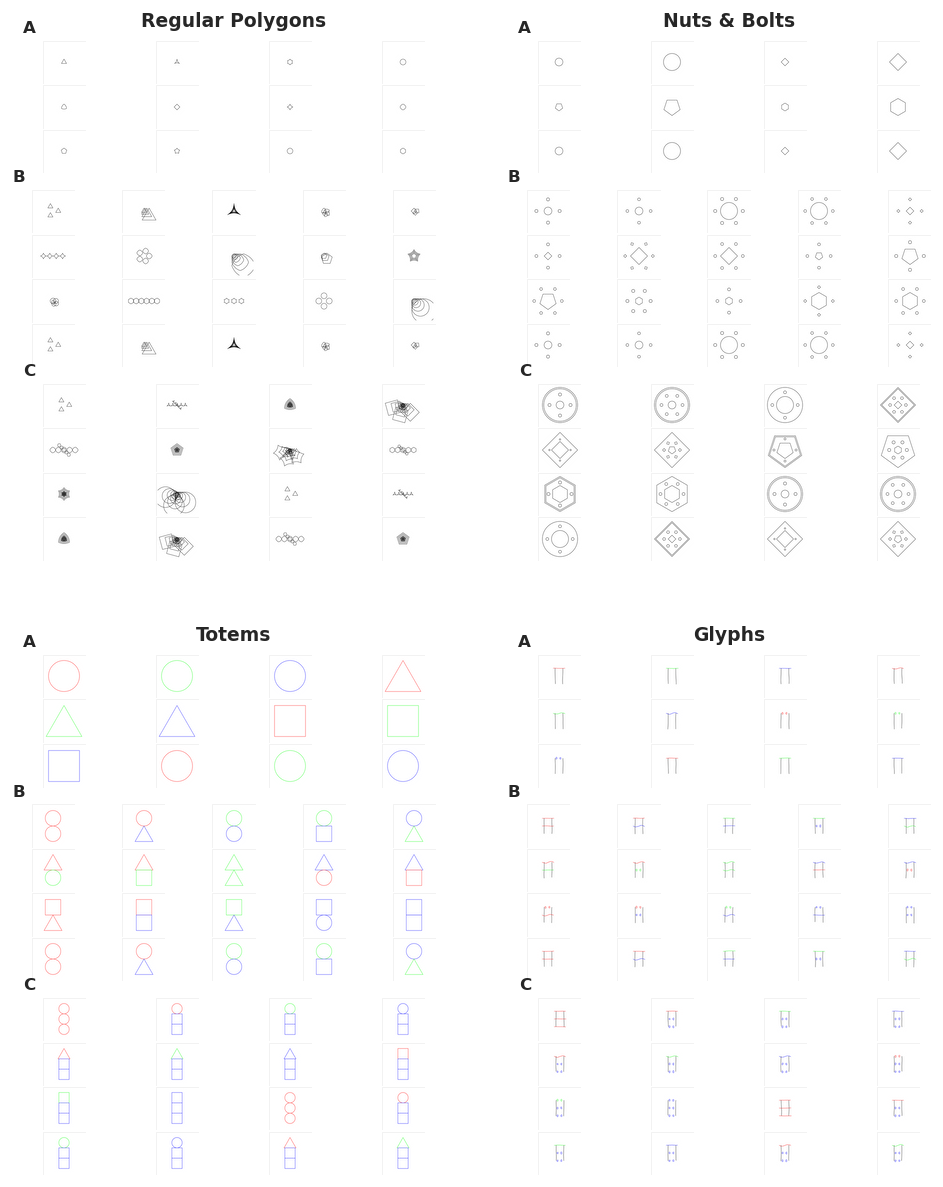


✓ SUCCESS! Created perfect figures with:
  • Individual PDFs for each domain
  • Combined 2×2 figure
  • Proper title spacing (no overlap)
  • Diverse image sampling (no redundancy)
  • Complete rows only (clean grids)
  • Science journal formatting


In [9]:
#!/usr/bin/env python
"""
Perfect stimulus variability figures with:
1. Proper spacing (no title overlap)
2. Intelligent diversity sampling (no redundancy)
3. Individual PDFs for each domain
4. Combined figure option
"""

import json
import random
import numpy as np
from pathlib import Path
from collections import defaultdict, OrderedDict
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import hashlib
from typing import List, Tuple, Dict

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Configure matplotlib for Science journal publication
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 7,
    'axes.titlesize': 8,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'mathtext.fontset': 'dejavusans',
})

# Paths
BASE = Path('/scratch/gpfs/nb0564/vlm_reasoning')
DATA_ROOT = BASE / 'balanced_data' / 'dim_balanced'
OUTP = BASE / 'plots' / 'publication'
OUTP.mkdir(parents=True, exist_ok=True)

# Complete grid configurations for clean layouts
GRID_CONFIGS = {
    'dim1': [
        (12, 4, 3),  # 4 columns × 3 rows = 12 images
        (12, 3, 4),  # 3 columns × 4 rows = 12 images
        (9, 3, 3),   # 3×3 = 9 images
        (8, 4, 2),   # 4×2 = 8 images
        (6, 3, 2),   # 3×2 = 6 images
    ],
    'dim2': [
        (20, 5, 4),  # 5×4 = 20 images
        (20, 4, 5),  # 4×5 = 20 images
        (18, 6, 3),  # 6×3 = 18 images
        (16, 4, 4),  # 4×4 = 16 images
        (15, 5, 3),  # 5×3 = 15 images
    ],
    'dim3': [
        (16, 4, 4),  # 4×4 = 16 images
        (15, 5, 3),  # 5×3 = 15 images
        (12, 4, 3),  # 4×3 = 12 images
        (12, 3, 4),  # 3×4 = 12 images
        (9, 3, 3),   # 3×3 = 9 images
    ]
}


class DiversitySampler:
    """Intelligent sampling to maximize diversity and avoid redundancy."""
    
    def __init__(self, use_image_hash=False):
        self.use_image_hash = use_image_hash
        self.seen_hashes = set()
        
    def compute_image_hash(self, img_path: Path) -> str:
        """Compute perceptual hash of image for duplicate detection."""
        try:
            img = Image.open(img_path).convert('RGB')
            # Resize to small size for hash
            img = img.resize((8, 8), Image.Resampling.LANCZOS)
            # Convert to grayscale
            pixels = np.array(img).mean(axis=2)
            # Compute average
            avg = pixels.mean()
            # Create binary hash
            diff = pixels > avg
            # Convert to hex string
            return hashlib.md5(diff.tobytes()).hexdigest()
        except:
            return str(img_path)
    
    def extract_diversity_features(self, img_path: Path) -> Dict:
        """Extract features from filename for diversity sampling."""
        name = img_path.stem
        features = {
            'path': img_path,
            'name': name,
            'variant': None,
            'index': None,
            'params': []
        }
        
        # Try to extract variant from path
        try:
            if 'var' in str(img_path):
                parts = str(img_path).split('/')
                for part in parts:
                    if part.startswith('var'):
                        features['variant'] = part
                        break
        except:
            pass
        
        # Try to extract index from filename
        try:
            # Common patterns: "0.png", "image_001.png", "trial_5_2.png"
            import re
            numbers = re.findall(r'\d+', name)
            if numbers:
                features['index'] = int(numbers[0])
                features['params'] = [int(n) for n in numbers]
        except:
            pass
        
        return features
    
    def sample_diverse(self, image_paths: List[Path], target_n: int) -> List[Path]:
        """Sample diverse images avoiding redundancy."""
        if len(image_paths) <= target_n:
            return image_paths
        
        # Extract features for all images
        featured_images = []
        for path in image_paths:
            features = self.extract_diversity_features(path)
            
            # Skip if we've seen this image before (by hash)
            if self.use_image_hash:
                img_hash = self.compute_image_hash(path)
                if img_hash in self.seen_hashes:
                    continue
                self.seen_hashes.add(img_hash)
                features['hash'] = img_hash
            
            featured_images.append(features)
        
        # Group by variant to ensure diversity across variants
        by_variant = defaultdict(list)
        for feat in featured_images:
            variant = feat['variant'] or 'default'
            by_variant[variant].append(feat)
        
        # Sample evenly across variants
        selected = []
        variants = list(by_variant.keys())
        
        # Calculate how many to take from each variant
        per_variant = max(1, target_n // len(variants))
        remainder = target_n % len(variants)
        
        for i, variant in enumerate(sorted(variants)):
            variant_images = by_variant[variant]
            
            # Take one extra from first few variants if remainder
            n_from_variant = per_variant + (1 if i < remainder else 0)
            n_from_variant = min(n_from_variant, len(variant_images))
            
            if n_from_variant > 0:
                # Sort by index/params for systematic sampling
                variant_images.sort(key=lambda x: (x['index'] or 0, x['name']))
                
                # Sample evenly distributed indices
                if len(variant_images) > n_from_variant:
                    indices = np.linspace(0, len(variant_images)-1, n_from_variant, dtype=int)
                    sampled = [variant_images[i] for i in indices]
                else:
                    sampled = variant_images
                
                selected.extend(sampled)
        
        # Trim to exact target if needed
        selected = selected[:target_n]
        
        # Return just the paths
        return [feat['path'] for feat in selected]


def find_available_domains() -> Tuple[List[str], Dict[str, str]]:
    """Dynamically find available domains."""
    domains = []
    domain_names = {}
    
    if DATA_ROOT.exists():
        for d in sorted(DATA_ROOT.iterdir()):
            if d.is_dir():
                # Check if it has dimension folders
                if any((d / f'dim{i}').exists() for i in [1, 2, 3]):
                    domain_key = d.name
                    domains.append(domain_key)
                    
                    # Create display name
                    if 'regular' in domain_key.lower() and 'polygon' in domain_key.lower():
                        display_name = 'Regular Polygons'
                    elif 'nuts' in domain_key.lower():
                        display_name = 'Nuts & Bolts'
                    elif 'totem' in domain_key.lower():
                        display_name = 'Totems'
                    elif 'glyph' in domain_key.lower():
                        display_name = 'Glyphs'
                    else:
                        display_name = domain_key.replace('_', ' ').title()
                    
                    domain_names[domain_key] = display_name
    
    # Order by priority
    priority_order = ['regular_polygons', 'nuts_and_bolts', 'totems', 'glyphs']
    ordered_domains = []
    
    for priority in priority_order:
        for domain in domains:
            if priority in domain or domain == priority:
                if domain not in ordered_domains:
                    ordered_domains.append(domain)
                    break
    
    # Add any remaining
    for domain in domains:
        if domain not in ordered_domains:
            ordered_domains.append(domain)
    
    return ordered_domains[:4], domain_names


def load_stimulus_image(path: Path, target_size=(100, 100), padding=6) -> np.ndarray:
    """Load and standardize stimulus image."""
    try:
        img = Image.open(path).convert('RGBA')
        
        # White background
        background = Image.new('RGBA', img.size, (255, 255, 255, 255))
        composite = Image.alpha_composite(background, img).convert('RGB')
        
        # Resize maintaining aspect ratio
        composite.thumbnail(
            (target_size[0] - 2*padding, target_size[1] - 2*padding), 
            Image.Resampling.LANCZOS
        )
        
        # Center on white canvas
        canvas = Image.new('RGB', target_size, (255, 255, 255))
        offset = ((target_size[0] - composite.size[0]) // 2,
                 (target_size[1] - composite.size[1]) // 2)
        canvas.paste(composite, offset)
        
        return np.array(canvas)
    except Exception as e:
        print(f"  Warning: Could not load {path}: {e}")
        return np.full((*target_size, 3), 255, dtype=np.uint8)


def collect_domain_images(domain: str, sampler: DiversitySampler) -> Dict[str, List[Path]]:
    """Collect diverse images for one domain."""
    domain_path = DATA_ROOT / domain
    collection = {'dim1': [], 'dim2': [], 'dim3': []}
    
    if not domain_path.exists():
        return collection
    
    print(f"\n  Collecting from {domain}:")
    
    for dim_idx in [1, 2, 3]:
        dim_path = domain_path / f'dim{dim_idx}'
        if not dim_path.exists():
            continue
        
        # Collect all images from all variants
        all_images = []
        variant_counts = {}
        
        for var_dir in sorted(dim_path.glob('var*')):
            images_dir = var_dir / 'images'
            if images_dir.exists():
                images = sorted(images_dir.glob('*.png'))
                variant_counts[var_dir.name] = len(images)
                all_images.extend(images)
        
        print(f"    dim{dim_idx}: {len(all_images)} total images from {len(variant_counts)} variants")
        
        if all_images:
            # Use diversity sampler to get representative subset
            max_per_dim = 60  # Maximum to consider per dimension
            sampled = sampler.sample_diverse(all_images, max_per_dim)
            collection[f'dim{dim_idx}'] = sampled
            print(f"           Selected {len(sampled)} diverse samples")
    
    return collection


def select_grid_layout(n_available: int, configs: List[Tuple[int, int, int]]) -> Tuple[int, int, int]:
    """Select optimal grid layout for available images."""
    if n_available == 0:
        return 0, 1, 1
    
    # Find best fitting configuration
    for n_total, cols, rows in configs:
        if n_total <= n_available:
            return n_total, cols, rows
    
    # Fallback for very few images
    if n_available >= 4:
        return 4, 2, 2
    elif n_available >= 2:
        return 2, 2, 1
    else:
        return 1, 1, 1


def create_dimension_panel(
    fig, gs_parent, 
    images: List[Path], 
    cols: int, rows: int,
    panel_label: str,
    show_label: bool = True
) -> None:
    """Create a single dimension panel with proper layout."""
    
    # Create grid for this dimension
    gs = gridspec.GridSpecFromSubplotSpec(
        rows, cols,
        subplot_spec=gs_parent,
        wspace=0.015, hspace=0.015
    )
    
    for idx, img_path in enumerate(images):
        if idx >= cols * rows:
            break
            
        row, col = idx // cols, idx % cols
        ax = fig.add_subplot(gs[row, col])
        
        # Load and display image
        img = load_stimulus_image(img_path)
        ax.imshow(img, interpolation='lanczos', aspect='equal')
        
        # Remove all axes
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Add subtle border
        rect = Rectangle(
            (0.5, 0.5), img.shape[1]-1, img.shape[0]-1,
            linewidth=0.25, edgecolor='#E8E8E8', 
            facecolor='none', transform=ax.transData
        )
        ax.add_patch(rect)
        
        # Add panel label to first image
        if idx == 0 and show_label:
            ax.text(
                -0.15, 1.12, panel_label,
                transform=ax.transAxes,
                fontsize=8, fontweight='bold',
                ha='right', va='bottom'
            )


def create_individual_domain_figure(
    domain: str, 
    domain_name: str,
    collection: Dict[str, List[Path]]
) -> plt.Figure:
    """Create a complete figure for one domain."""
    
    # Determine grid layouts
    dim1_n, dim1_cols, dim1_rows = select_grid_layout(
        len(collection['dim1']), GRID_CONFIGS['dim1']
    )
    dim2_n, dim2_cols, dim2_rows = select_grid_layout(
        len(collection['dim2']), GRID_CONFIGS['dim2']
    )
    dim3_n, dim3_cols, dim3_rows = select_grid_layout(
        len(collection['dim3']), GRID_CONFIGS['dim3']
    )
    
    # Select images
    dim1_images = collection['dim1'][:dim1_n]
    dim2_images = collection['dim2'][:dim2_n]
    dim3_images = collection['dim3'][:dim3_n]
    
    print(f"\n  Layout for {domain_name}:")
    print(f"    Dim 1: {len(dim1_images)} images in {dim1_cols}×{dim1_rows} grid")
    print(f"    Dim 2: {len(dim2_images)} images in {dim2_cols}×{dim2_rows} grid")
    print(f"    Dim 3: {len(dim3_images)} images in {dim3_cols}×{dim3_rows} grid")
    
    # Skip if no images
    if not any([dim1_images, dim2_images, dim3_images]):
        print(f"    No images found for {domain_name}, skipping")
        return None
    
    # Calculate figure dimensions
    max_cols = max(dim1_cols, dim2_cols, dim3_cols, 1)
    total_rows = dim1_rows + dim2_rows + dim3_rows
    
    # Science double column width
    fig_width = 4.49  # inches
    panel_width = fig_width / max_cols * 0.88
    fig_height = panel_width * total_rows * 1.1
    
    # Add space for title
    fig_height += 0.4
    
    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
    
    # Build panels list
    panels = []
    if dim1_images:
        panels.append(('dim1', dim1_images, dim1_cols, dim1_rows))
    if dim2_images:
        panels.append(('dim2', dim2_images, dim2_cols, dim2_rows))
    if dim3_images:
        panels.append(('dim3', dim3_images, dim3_cols, dim3_rows))
    
    # Calculate height ratios
    height_ratios = [p[3] for p in panels]  # p[3] is rows
    
    # Create main grid with proper spacing for title
    gs_main = gridspec.GridSpec(
        len(panels), 1,
        figure=fig,
        left=0.06, right=0.94,
        top=0.92,  # Leave space for title
        bottom=0.04,
        hspace=0.12,  # Space between dimension panels
        height_ratios=height_ratios
    )
    
    # Add title with proper spacing
    fig.suptitle(
        f'{domain_name}',
        fontsize=11, fontweight='bold',
        y=0.96  # Position above plots
    )
    
    # Create each dimension panel
    panel_labels = ['A', 'B', 'C']
    
    for panel_idx, (dim_name, images, cols, rows) in enumerate(panels):
        create_dimension_panel(
            fig, gs_main[panel_idx],
            images, cols, rows,
            panel_labels[panel_idx],
            show_label=True
        )
        
        # Add dimension annotation
        dim_num = dim_name[-1]
        bbox = gs_main[panel_idx].get_position(fig)
        fig.text(
            bbox.x1 + 0.01, bbox.y0 + bbox.height/2,
            f'Dimension {dim_num}',
            rotation=270, ha='left', va='center',
            fontsize=7, color='#666666',
            transform=fig.transFigure
        )
    
    plt.tight_layout()
    return fig


def create_combined_figure(
    all_collections: Dict[str, Dict[str, List[Path]]],
    domain_names: Dict[str, str]
) -> plt.Figure:
    """Create combined 2×2 figure with all domains."""
    
    # Science full page width
    fig_width = 6.85  # inches
    fig_height = 8.5  # inches
    
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
    
    # Main 2×2 grid
    gs_main = gridspec.GridSpec(
        2, 2,
        figure=fig,
        left=0.04, right=0.96,
        top=0.93,  # More space from top
        bottom=0.04,
        wspace=0.1,  # Horizontal spacing
        hspace=0.18  # Vertical spacing for titles
    )
    
    # Create each domain section
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    domains = list(all_collections.keys())[:4]
    
    for idx, domain in enumerate(domains):
        if idx >= 4:
            break
            
        row, col = positions[idx]
        collection = all_collections[domain]
        domain_name = domain_names.get(domain, domain.replace('_', ' ').title())
        
        # Get layouts
        dim1_n, dim1_cols, dim1_rows = select_grid_layout(
            len(collection['dim1']), GRID_CONFIGS['dim1']
        )
        dim2_n, dim2_cols, dim2_rows = select_grid_layout(
            len(collection['dim2']), GRID_CONFIGS['dim2']
        )
        dim3_n, dim3_cols, dim3_rows = select_grid_layout(
            len(collection['dim3']), GRID_CONFIGS['dim3']
        )
        
        # Select images
        dim1_images = collection['dim1'][:dim1_n]
        dim2_images = collection['dim2'][:dim2_n]
        dim3_images = collection['dim3'][:dim3_n]
        
        # Skip if no images
        if not any([dim1_images, dim2_images, dim3_images]):
            continue
        
        # Build panels
        panels = []
        height_ratios = []
        if dim1_images:
            panels.append(('dim1', dim1_images, dim1_cols, dim1_rows))
            height_ratios.append(dim1_rows)
        if dim2_images:
            panels.append(('dim2', dim2_images, dim2_cols, dim2_rows))
            height_ratios.append(dim2_rows)
        if dim3_images:
            panels.append(('dim3', dim3_images, dim3_cols, dim3_rows))
            height_ratios.append(dim3_rows)
        
        if not panels:
            continue
        
        # Create subsection grid
        gs_domain = gridspec.GridSpecFromSubplotSpec(
            len(panels), 1,
            subplot_spec=gs_main[row, col],
            hspace=0.1,
            height_ratios=height_ratios
        )
        
        # Add domain title with proper spacing
        bbox = gs_main[row, col].get_position(fig)
        fig.text(
            bbox.x0 + bbox.width/2, 
            bbox.y1 + 0.008,  # Small space above section
            domain_name,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            transform=fig.transFigure
        )
        
        # Create dimension panels
        panel_labels = ['A', 'B', 'C']
        
        for panel_idx, (dim_name, images, cols, rows) in enumerate(panels):
            # Scale down image size for combined figure
            create_dimension_panel(
                fig, gs_domain[panel_idx],
                images, cols, rows,
                panel_labels[panel_idx],
                show_label=True
            )
    
    plt.tight_layout()
    return fig


def main():
    """Main execution."""
    print("=" * 70)
    print("CREATING PERFECT STIMULUS VARIABILITY FIGURES")
    print("=" * 70)
    
    # Find available domains
    domains, domain_names = find_available_domains()
    
    if not domains:
        print("\nERROR: No domains found!")
        print(f"Please check that {DATA_ROOT} exists and contains domain folders")
        return
    
    print(f"\nFound {len(domains)} domains:")
    for d in domains:
        print(f"  - {d} → {domain_names.get(d, d)}")
    
    # Initialize diversity sampler
    sampler = DiversitySampler(use_image_hash=False)  # Set True to check for duplicates
    
    # Collect images for all domains
    print("\n" + "=" * 70)
    print("COLLECTING DIVERSE IMAGES")
    print("=" * 70)
    
    all_collections = {}
    for domain in domains:
        collection = collect_domain_images(domain, sampler)
        all_collections[domain] = collection
    
    # Create individual domain figures
    print("\n" + "=" * 70)
    print("CREATING INDIVIDUAL DOMAIN FIGURES")
    print("=" * 70)
    
    for domain in domains:
        domain_name = domain_names.get(domain, domain)
        print(f"\nCreating figure for {domain_name}...")
        
        fig = create_individual_domain_figure(
            domain, domain_name, all_collections[domain]
        )
        
        if fig:
            # Save individual domain figure
            output_path = OUTP / f'stimulus_{domain}_perfect.pdf'
            fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
            print(f"  ✓ Saved: {output_path}")
            
            # Also save PNG version
            output_path_png = OUTP / f'stimulus_{domain}_perfect.png'
            fig.savefig(output_path_png, dpi=600, bbox_inches='tight', pad_inches=0.1)
            print(f"  ✓ Saved: {output_path_png}")
            
            plt.close(fig)
    
    # Create combined figure
    print("\n" + "=" * 70)
    print("CREATING COMBINED FIGURE")
    print("=" * 70)
    
    combined_fig = create_combined_figure(all_collections, domain_names)
    
    if combined_fig:
        output_path = OUTP / 'stimulus_all_domains_combined_perfect.pdf'
        combined_fig.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"\n✓ Saved combined: {output_path}")
        
        output_path_png = OUTP / 'stimulus_all_domains_combined_perfect.png'
        combined_fig.savefig(output_path_png, dpi=600, bbox_inches='tight', pad_inches=0.1)
        print(f"✓ Saved combined: {output_path_png}")
        
        plt.show()
    
    # Summary
    print("\n" + "=" * 70)
    print("✓ SUCCESS! Created perfect figures with:")
    print("  • Individual PDFs for each domain")
    print("  • Combined 2×2 figure")
    print("  • Proper title spacing (no overlap)")
    print("  • Diverse image sampling (no redundancy)")
    print("  • Complete rows only (clean grids)")
    print("  • Science journal formatting")
    print("=" * 70)


if __name__ == "__main__":
    main()

In [10]:
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results_path = '/scratch/gpfs/nb0564/vlm_reasoning/output/None/gemini-flash_final'
all_results = glob(results_path + '/*.csv')
results_df = pd.concat([pd.read_csv(f) for f in all_results])
results_df.groupby(['n_dimensions', 'reference_variance']).sample()

,trial_idx,summary_path,oddball_idx,oddball_abstraction,reference_variance,n_dimensions,abstraction_columns,response,answer,n_input_tokens,n_thought_tokens,n_output_tokens
83,83,data/regular_polygons_corrected/dim1/var0/summ...,6,edge_type,0,1,"n_sides,edge_type","[6] {The shape in image 6 has rounded corners,...",6,1599,0,27
79,79,data/regular_polygons_corrected/dim1/var1/summ...,2,n_sides,1,1,"n_sides,edge_type",[2] {Image 2 is the outlier because it has 6 p...,2,1599,0,26
48,48,data/regular_polygons/dim2/var0/summaries/summ...,2,edge_type,0,2,"n_sides,edge_type,transform_type,n_copies","[2] {Image 2 shows three circles, while all ot...",2,1599,0,22
98,98,data/regular_polygons/dim2/var1/summaries/summ...,3,edge_type,1,2,"n_sides,edge_type,transform_type,n_copies",[3] {All other images show nested polygons (pe...,3,1599,0,25
94,94,data/regular_polygons/dim2/var2/summaries/summ...,5,edge_type,2,2,"n_sides,edge_type,transform_type,n_copies",[5] {All other images show nested polygons wit...,5,1599,0,30
58,58,data/regular_polygons/dim2/var3/summaries/summ...,1,n_sides,3,2,"n_sides,edge_type,transform_type,n_copies",[4] {The other five images consist of concentr...,4,1599,0,43
78,78,data/regular_polygons/dim3/var0/summaries/summ...,1,comp_scale,0,3,"n_sides,edge_type,transform_type,n_copies,comp...",[1] {The central element of image 1 has four s...,1,1599,0,27
80,80,data/regular_polygons/dim3/var1/summaries/summ...,6,transform_type,1,3,"n_sides,edge_type,transform_type,n_copies,comp...","[6] {Images 1, 2, 3, 4, and 5 display a symmet...",6,1599,0,33
92,92,data/regular_polygons/dim3/var2/summaries/summ...,4,n_copies,2,3,"n_sides,edge_type,transform_type,n_copies,comp...",[4] {This image displays a pattern that repeat...,4,1599,0,58
17,17,data/regular_polygons_corrected/dim3/var3/summ...,4,n_sides,3,3,"n_sides,edge_type,transform_type,n_copies,comp...",[4] {This image displays a spiral composed of ...,4,1599,0,29


In [ ]:
# --- AUDIT: recompute per-trial edit distances and compare to saved CSV ---
import json, re, csv, math
from pathlib import Path
import numpy as np, pandas as pd

BASE    = Path('/scratch/gpfs/nb0564/vlm_reasoning')
BAL_DATA = BASE / 'balanced_data'
RAW_DATA = BASE / 'data'
ED_CSV  = BASE / 'analysis' / 'per_trial_edit_distance.csv'
AUDIT_TSV = BASE / 'analysis' / 'edit_distance_audit.tsv'

EXCLUDE_META_COLS = {"program_string","render_filepath","filepath","file","id"}

def tok(s): 
    return re.findall(r"[()]|[^\s()]+", (s or "").strip())

def lev_tokens(a, b):
    A, B = tok(a), tok(b)
    n, m = len(A), len(B)
    if n == 0: return m
    if m == 0: return n
    dp = list(range(m+1))
    for i in range(1, n+1):
        prev, dp[0] = dp[0], i
        ai = A[i-1]
        for j in range(1, m+1):
            ins  = dp[j-1] + 1
            dele = dp[j]   + 1
            sub  = prev + (0 if ai == B[j-1] else 1)
            prev, dp[j] = dp[j], min(ins, dele, sub)
    return dp[m]

def norm(v):
    if isinstance(v, (int,float)): 
        return int(v) if float(v).is_integer() else float(v)
    if isinstance(v, bool): return int(v)
    s = str(v).strip()
    try:
        f = float(s)
        return int(f) if f.is_integer() else f
    except:
        return s

def read_csv_dicts(p: Path):
    with p.open() as f:
        r = csv.DictReader(f)
        return r.fieldnames or [], [dict(row) for row in r]

def build_maps(meta_csv: Path):
    # returns (stimulus_idx -> program_string, features_tuple -> program_string)
    hdr, rows = read_csv_dicts(meta_csv)
    stim2prog, feat2prog = {}, {}
    has_stim = "stimulus_idx" in (hdr or [])
    for r in rows:
        prog = (r.get("program_string") or "").strip()
        if not prog: 
            continue
        if has_stim and r.get("stimulus_idx") not in (None, ""):
            try:
                stim2prog[int(float(r["stimulus_idx"]))] = prog
            except:
                pass
        # features map as fallback
        items = [(k, norm(v)) for k,v in r.items() if k not in EXCLUDE_META_COLS]
        feat2prog[tuple(sorted(items))] = prog
    return stim2prog, feat2prog

def bucket_path(mode, domain, dim, var) -> Path:
    dim_s, var_s = f"dim{dim}", f"var{var}"
    if mode == "data":
        return RAW_DATA / domain / dim_s / var_s
    elif mode == "dim_balanced":
        return BAL_DATA / "dim_balanced" / domain / dim_s / var_s
    elif mode == "var_balanced":
        return BAL_DATA / "var_balanced" / domain / dim_s / var_s
    else:
        raise ValueError(mode)

def iter_trials_jsonl(p: Path):
    with p.open() as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            try:
                yield json.loads(ln)
            except json.JSONDecodeError:
                # bad line → skip
                continue


def tile_prog(tile, stim2prog, feat2prog):
    # prefer a direct stimulus index if present
    for k in ["stimulus_idx","stimulus_id","stimulus","idx","id"]:
        if k in tile:
            try:
                return stim2prog[int(float(tile[k]))]
            except:
                pass
        if isinstance(tile, dict) and "features" in tile and k in tile["features"]:
            try:
                return stim2prog[int(float(tile["features"][k]))]
            except:
                pass
    # else fall back to features mapping
    feats = tile.get("features", tile if isinstance(tile, dict) else {})
    items = [(k, norm(v)) for k,v in feats.items() if k not in EXCLUDE_META_COLS]
    return feat2prog.get(tuple(sorted(items)))

# --- load saved distances
ed = pd.read_csv(ED_CSV)
if ed.empty:
    raise SystemExit(f"Empty distances CSV at {ED_CSV}")

rows = []
mismatch_examples = []
for i, r in ed.iterrows():
    mode, domain, dim, var = r["mode"], r["domain"], int(r["dim"]), int(r["var"])
    trial_idx = int(r["trial_idx"])
    oddball_1b = int(r["oddball_idx"])
    n_tiles = int(r["n_tiles"])
    avg_saved = float(r["avg_edit_distance"])
    dists_saved = [float(x) for x in json.loads(r["distances_json"])]

    bpath = bucket_path(mode, domain, dim, var)
    meta_csv = bpath / "metadata.csv"
    trials_jsonl = bpath / "trials.jsonl"
    if not (meta_csv.exists() and trials_jsonl.exists()):
        rows.append({**r.to_dict(), "audit_status":"missing_files"})
        continue

    stim2prog, feat2prog = build_maps(meta_csv)

    # find that trial in jsonl
    found = None
    for tr in iter_trials_jsonl(trials_jsonl):
        if int(tr.get("trial_idx", -99999)) == trial_idx:
            found = tr
            break
    if not found:
        rows.append({**r.to_dict(), "audit_status":"trial_not_found"})
        continue

    tiles = found.get("tiles") or []
    if len(tiles) != n_tiles:
        rows.append({**r.to_dict(), "audit_status":f"n_tiles_mismatch_saved={n_tiles}_found={len(tiles)}"})
        continue

    prog_list = []
    unresolved = False
    for t in tiles:
        p = tile_prog(t, stim2prog, feat2prog)
        if not p:
            unresolved = True
            break
        prog_list.append(p)
    if unresolved or not prog_list:
        rows.append({**r.to_dict(), "audit_status":"unresolved_programs"})
        continue

    odd0 = max(0, oddball_1b - 1)
    if not (0 <= odd0 < len(prog_list)):
        rows.append({**r.to_dict(), "audit_status":"bad_oddball_index"})
        continue

    odd_prog = prog_list[odd0]
    dists_re = []
    for j, rp in enumerate(prog_list):
        if j == odd0: 
            continue
        dists_re.append(float(lev_tokens(odd_prog, rp)))

    # comparisons
    ok_len   = (len(dists_re) == len(dists_saved))
    ok_avg   = abs((sum(dists_re)/len(dists_re)) - avg_saved) <= 1e-6
    ok_multiset = (sorted(round(x,6) for x in dists_re) == sorted(round(x,6) for x in dists_saved))

    status = "ok" if (ok_len and ok_avg and ok_multiset) else "mismatch"
    if status == "mismatch" and len(mismatch_examples) < 8:
        mismatch_examples.append({
            "bucket": str(bpath),
            "trial_idx": trial_idx,
            "saved_avg": avg_saved,
            "recomp_avg": sum(dists_re)/len(dists_re),
            "saved_dists": dists_saved,
            "recomp_dists": dists_re
        })

    rows.append({
        "mode": mode, "domain": domain, "dim": dim, "var": var, "trial_idx": trial_idx,
        "n_tiles": n_tiles, "oddball_idx": oddball_1b,
        "saved_avg": avg_saved, "recomp_avg": sum(dists_re)/len(dists_re),
        "len_saved": len(dists_saved), "len_recomp": len(dists_re),
        "multiset_match": int(ok_multiset),
        "avg_match": int(ok_avg),
        "audit_status": status
    })

audit_df = pd.DataFrame(rows)
audit_df.to_csv(AUDIT_TSV, sep="\t", index=False)

print("=== EDIT DISTANCE AUDIT SUMMARY ===")
print(audit_df["audit_status"].value_counts(dropna=False))
print("\nExamples (up to 8) of mismatches:\n")
for ex in mismatch_examples:
    print(json.dumps(ex, indent=2)[:1200], "\n---")

print(f"\nSaved audit report: {AUDIT_TSV}")


Exception ignored in: <generator object iter_trials_jsonl at 0x151970451af0>
Traceback (most recent call last):
  File "/tmp/ipykernel_2833790/274048559.py", line 137, in <module>
RuntimeError: generator ignored GeneratorExit
Exception ignored in: <generator object iter_trials_jsonl at 0x151970451af0>
Traceback (most recent call last):
  File "/tmp/ipykernel_2833790/274048559.py", line 137, in <module>
RuntimeError: generator ignored GeneratorExit


Exception ignored in: <generator object iter_trials_jsonl at 0x151965eb7060>
Traceback (most recent call last):
  File "/tmp/ipykernel_2833790/274048559.py", line 137, in <module>
RuntimeError: generator ignored GeneratorExit
Exception ignored in: <generator object iter_trials_jsonl at 0x151965eb7060>
Traceback (most recent call last):
  File "/tmp/ipykernel_2833790/274048559.py", line 137, in <module>
RuntimeError: generator ignored GeneratorExit
Exception ignored in: <generator object iter_trials_jsonl at 0x151965eb7060>
Traceback (most recent call last):
  File "/tmp/ipykernel_2833790/274048559.py", line 137, in <module>
RuntimeError: generator ignored GeneratorExit
Exception ignored in: <generator object iter_trials_jsonl at 0x151965eb7060>
Traceback (most recent call last):
  File "/tmp/ipykernel_2833790/274048559.py", line 137, in <module>
RuntimeError: generator ignored GeneratorExit
Exception ignored in: <generator object iter_trials_jsonl at 0x151965eb7060>
Traceback (most rec

KeyboardInterrupt: 

In [ ]:
# --- PLOT: Accuracy vs Edit Distance for balanced runs (dim_balanced & var_balanced) ---
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Reuse your load_balanced_accuracy(), ci_boot(), style_axes(), DOMAINS, BASE, OUTP from the earlier cell
ED_CSV = BASE / 'analysis' / 'per_trial_edit_distance.csv'

# 1) Load per-trial accuracy for balanced sets
acc_dimB = load_balanced_accuracy('dim_balanced')   # ['domain','dim','var','trial_idx','is_correct']
acc_varB = load_balanced_accuracy('var_balanced')

# 2) Load per-trial edit distances
ed = pd.read_csv(ED_CSV)
# keep only balanced modes
edB_dim = ed.query("mode == 'dim_balanced'").copy()
edB_var = ed.query("mode == 'var_balanced'").copy()

# 3) Join accuracy ↔︎ distances on (domain, dim, var, trial_idx)
on_keys = ['domain','dim','var','trial_idx']
# enforce int typing (trial_idx sometimes comes as object)
for df in (acc_dimB, acc_varB, edB_dim, edB_var):
    if 'trial_idx' in df.columns:
        df['trial_idx'] = pd.to_numeric(df['trial_idx'], errors='coerce').astype('Int64')

dim_join = (acc_dimB.merge(edB_dim[on_keys + ['avg_edit_distance']], on=on_keys, how='inner')
                     .rename(columns={'avg_edit_distance':'edit_dist'}))
var_join = (acc_varB.merge(edB_var[on_keys + ['avg_edit_distance']], on=on_keys, how='inner')
                     .rename(columns={'avg_edit_distance':'edit_dist'}))

# 4) Helper: quantile-bin edit distances, compute mean ± CI per bin
def bin_and_ci(df, x='edit_dist', y='is_correct', q=12):
    df = df.dropna(subset=[x, y]).copy()
    if df.empty:
        return pd.DataFrame(columns=['x_mid','mean','lo','hi','n'])
    # make quantile bins; drop duplicates (if many equal values)
    try:
        bins = pd.qcut(df[x], q=q, duplicates='drop')
    except ValueError:
        # fall back to equal-width bins if qcut fails
        bins = pd.cut(df[x], bins=min(q, max(2, df[x].nunique())))
    df['__bin'] = bins
    rec = []
    for b, g in df.groupby('__bin', observed=True):
        if isinstance(b, pd.Interval):
            x_mid = 0.5*(b.left + b.right)
        else:
            # if categorical left over, take median
            x_mid = float(g[x].median())
        m, lo, hi = ci_boot(g[y].values)
        rec.append((x_mid, m, lo, hi, len(g)))
    out = pd.DataFrame(rec, columns=['x_mid','mean','lo','hi','n']).sort_values('x_mid')
    return out

# 5) Plot (dim_balanced)
P = bin_and_ci(dim_join, x='edit_dist', y='is_correct', q=12)
fig, ax = plt.subplots(figsize=(4.0,3.4), constrained_layout=True)
if not P.empty:
    ax.plot(P['x_mid'], P['mean'], color='#1f78b4', marker='o', markersize=4.2, lw=1.8)
    ax.fill_between(P['x_mid'], P['lo'], P['hi'], color='#1f78b4', alpha=0.15, linewidth=0)
    for _, r in P.iterrows():
        ax.annotate(f"n={int(r['n'])}", (r['x_mid'], r['mean']), xytext=(0,-10),
                    textcoords='offset points', ha='center', va='top', fontsize=7.5, color='#777777')
ax.set_xlabel('Edit distance (avg oddball vs refs)')
style_axes(ax, 'Accuracy vs Edit Distance (Dim-balanced)')
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:.0f}' if abs(x-round(x))<1e-6 else f'{x:.1f}'))
fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.18)
fig.savefig(OUTP/'balanced_accuracy_vs_edit_dim.pdf'); plt.close(fig)
print('Saved:', OUTP/'balanced_accuracy_vs_edit_dim.pdf')

# 6) Plot (var_balanced)
P = bin_and_ci(var_join, x='edit_dist', y='is_correct', q=12)
fig, ax = plt.subplots(figsize=(4.0,3.4), constrained_layout=True)
if not P.empty:
    ax.plot(P['x_mid'], P['mean'], color='#6F4C9B', marker='o', markersize=4.2, lw=1.8)
    ax.fill_between(P['x_mid'], P['lo'], P['hi'], color='#6F4C9B', alpha=0.15, linewidth=0)
    for _, r in P.iterrows():
        ax.annotate(f"n={int(r['n'])}", (r['x_mid'], r['mean']), xytext=(0,-10),
                    textcoords='offset points', ha='center', va='top', fontsize=7.5, color='#777777')
ax.set_xlabel('Edit distance (avg oddball vs refs)')
style_axes(ax, 'Accuracy vs Edit Distance (Var-balanced)')
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'{x:.0f}' if abs(x-round(x))<1e-6 else f'{x:.1f}'))
fig.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.18)
fig.savefig(OUTP/'balanced_accuracy_vs_edit_var.pdf'); plt.close(fig)
print('Saved:', OUTP/'balanced_accuracy_vs_edit_var.pdf')


NameError: name 'load_balanced_accuracy' is not defined